#### "Herramientas utilizadas"  ✔ ✖
-------
- **numpy ✔**
- **pandas ✔**
- **matplotlib o seaborn**  ✔ 
- **scikit-learn**
- **scipy**
- **nltk o spaCy**

### P 1 (Eleccion y descripcion del corpus)

El corpus utilizado en este proyecto corresponde a una colección de discursos inaugurales de presidentes de Estados Unidos, 
obtenida desde la plataforma Kaggle. Este conjunto de datos contiene un total de 58 documentos, que abarcan desde el primer presidente, 
George Washington (1789), hasta Donald Trump (2017).

Cada documento consiste en el texto completo de un discurso inaugural y está acompañado de metadatos, tales como el nombre del presidente
y la fecha del discurso. Estos textos presentan una extensión considerable y un lenguaje formal, lo que los hace adecuados para un análisis 
semántico.

https://www.kaggle.com/datasets/adhok93/presidentialaddress

### P 2 (Hipotesis inicial)

Se espera que los discursos presidenciales compartan una estructura semántica común centrada en conceptos como libertad, nación, gobierno y economía. Se anticipa que el análisis mediante SVD permitirá identificar estos temas latentes y agrupar discursos similares en el espacio reducido. Además, se espera observar cierta separación entre discursos de distintos periodos históricos, reflejando cambios en el lenguaje y en las prioridades políticas a lo largo del tiempo.



(4863, 58)


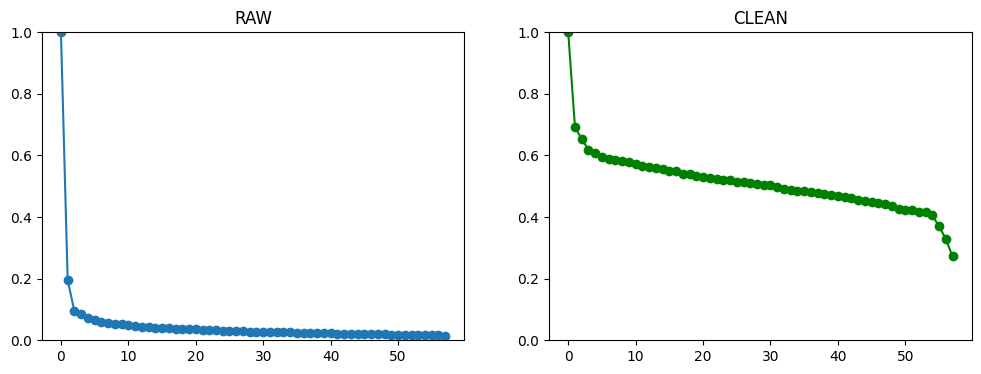

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS

# =========================
# 1. CARGA DE DATOS
# =========================
ruta = os.path.join("archive (3)", "inaug_speeches.csv")
df = pd.read_csv(ruta, encoding="latin1")

df["text"] = df["text"].fillna("")

# =========================
# 2. LIMPIEZA
# =========================
def clean(text):
    text = text.lower()
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["text_clean"] = df["text"].apply(clean)

# =========================
# 3. STOPWORDS PERSONALIZADAS
# =========================
palabras_ruido = set([
    'shall', 'let', 'make', 'know', 'just', 'great', 'new', 'good', 'best',
    'government', 'people', 'states', 'united', 'america', 'american',
    'country', 'nation', 'fellow', 'years', 'time', "life", "men", "today", "day"
])

stopwords_final = list(palabras_ruido.union(ENGLISH_STOP_WORDS))

# =========================
# 4. MATRIZ RAW (SIN LIMPIEZA)
# =========================
vectorizer_raw = CountVectorizer()
X_raw = vectorizer_raw.fit_transform(df["text"]).toarray()

# =========================
# 5. MATRIZ CLEAN (TF-IDF + STOPWORDS)
# =========================
vectorizer_clean = TfidfVectorizer(
    stop_words=stopwords_final,
    min_df=2,  #aparecen en al menos 2 archivos
    max_df=0.7 # No aparece más de un 70% en los archivos 
)

X_clean = vectorizer_clean.fit_transform(df["text_clean"]).toarray()
X_clean = X_clean.T    # palabras filas y documentos columnas
print(X_clean.shape)

terminos_clean = vectorizer_clean.get_feature_names_out()

# =========================
# 6. NORMALIZACIÓN
# =========================
X_raw = X_raw / (X_raw.sum(axis=1, keepdims=True) + 1e-9)
X_clean = X_clean / (X_clean.sum(axis=1, keepdims=True) + 1e-9)

# =========================
# 7. SVD
# =========================
U_raw, s_raw, VT_raw = np.linalg.svd(X_raw, full_matrices=False)
U_clean, s_clean, VT_clean = np.linalg.svd(X_clean, full_matrices=False)  # -> A=UΣVT

# =========================
# 8. VALORES SINGULARES
# =========================
s_raw_norm = s_raw / s_raw[0]
s_clean_norm = s_clean / s_clean[0]

y_max = max(s_raw_norm.max(), s_clean_norm.max())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(s_raw_norm, marker="o")
axes[0].set_title("RAW")
axes[0].set_ylim(0, y_max)

axes[1].plot(s_clean_norm, marker="o", color="green")
axes[1].set_title("CLEAN")
axes[1].set_ylim(0, y_max)

plt.show()



- 4863 filas : Documentos

- 58 columnas : Palabras



## P 3 (Preprocesamiento del texto).

1.-Se realizó una tokenización automática utilizando TfidfVectorizer, que separa el texto en palabras individuales.

2.-Para limpiar el contenido fue utilizada la normalización, todo el texto fue convertido a minúsculas y se eliminaron números, signos de puntuación y carácteres no alfabéticos
 
3.-Utilizando ENGLISH_STOP_WORDS se eliminaron las palabras comunes del inglés que no aportan información además, palabras como “government”, “people” y “nation” fueron agregadas a un conjunto de palabras muy utilizadas en discursos pero que estregan poca información del corpus.

4.-Se aplicó un filtrado de términos mediante los parámetros min_df=2 y max_df=0.7. Esto permitió eliminar palabras muy poco frecuentes (que aparecen en menos de dos documentos) y palabras demasiado frecuentes (presentes en más del 70% de los textos), reduciendo así el ruido y mejorando la calidad de la representación del corpus.


## P4 (Construcción de la matriz textual)

Se construyó una matriz término-documento a partir de los textos utilizando TfidfVectorizer. 
Dado que esta herramienta genera inicialmente una matriz documento-término, se realizó una 
transposición para seguir la convención utilizada en clases.

La matriz obtenida tiene dimensión 4863×58, donde 4863 corresponde al número de términos 
distintos y 58 al número de documentos analizados.

Cada entrada A ij representa el valor TF-IDF del término i en el documento j, lo que indica
la importancia relativa de dicho término dentro del documento, considerando también su frecuencia 
en el conjunto total de textos.



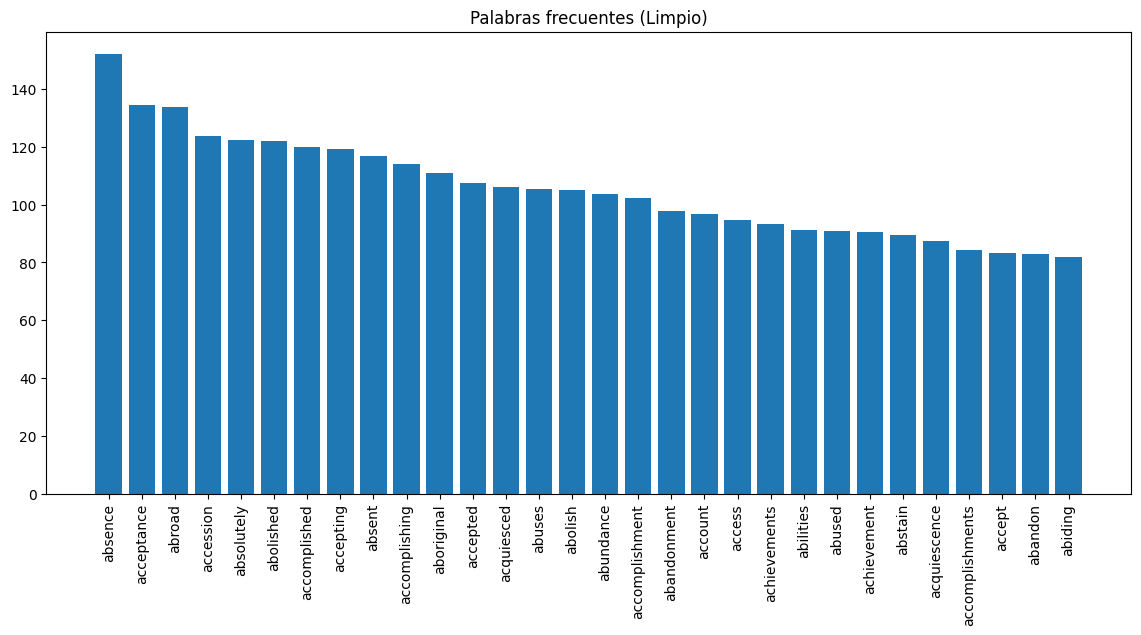

In [15]:
# =========================
# 9. PALABRAS FRECUENTES 
# =========================
words = vectorizer_clean.get_feature_names_out()
freqs = np.array(X_clean.sum(axis=0)).flatten()

idx = np.argsort(freqs)[::-1]

top_n = 30
top_words = [words[i] for i in idx[:top_n]]
top_counts = freqs[idx[:top_n]]

plt.figure(figsize=(14,6))
plt.bar(top_words, top_counts)
plt.xticks(rotation=90)
plt.title("Palabras frecuentes (Limpio)")
plt.show()



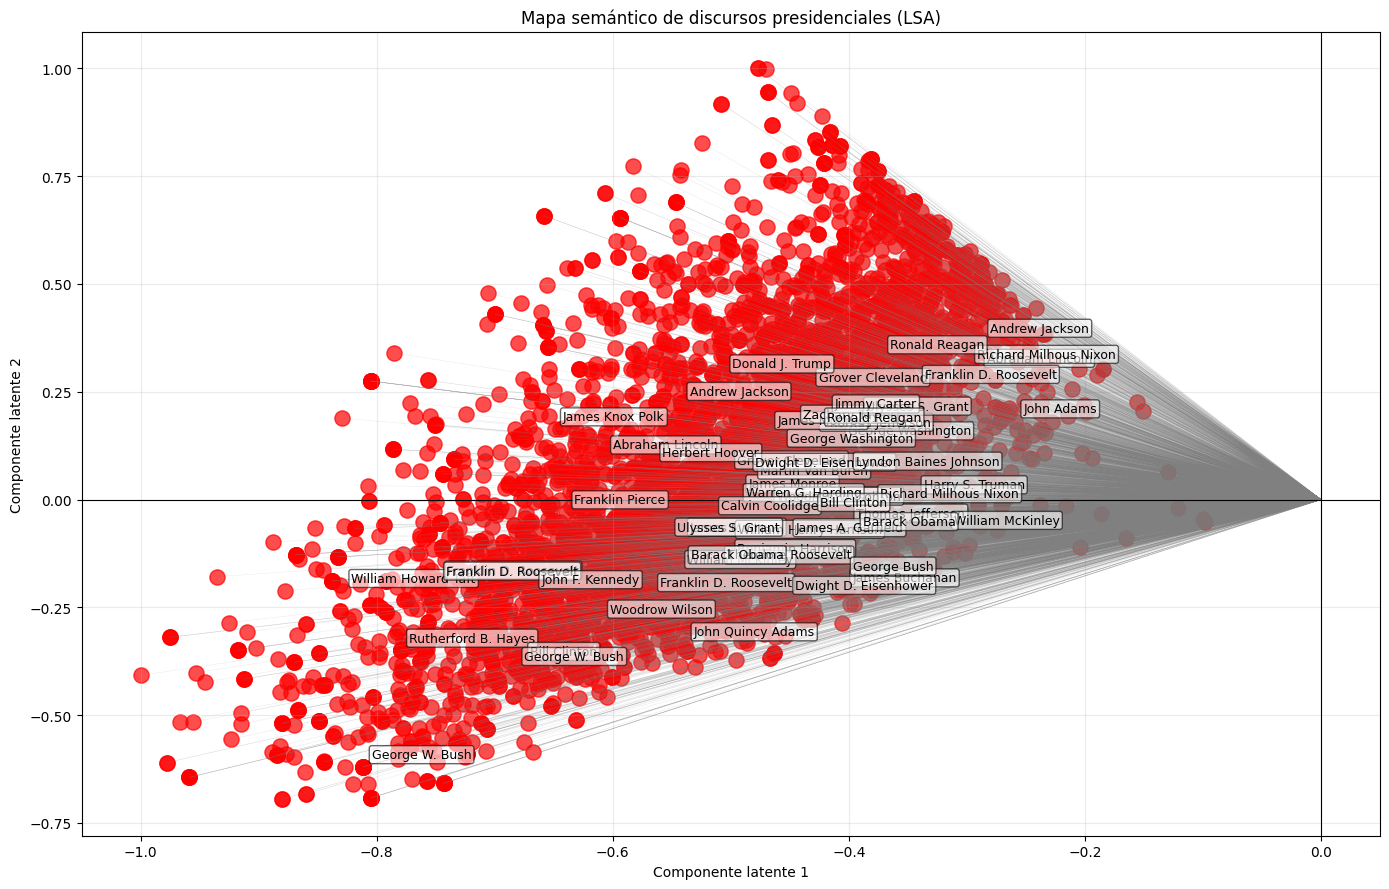


PALABRAS MÁS REPRESENTATIVAS POR COMPONENTE:

Componente 1:  ['accountability', 'abreast', 'achieved', 'accordance', 'accounted', 'achieve', 'accessible', 'abundant', 'according', 'abandoned']
Componente 2:  ['acknowledging', 'acknowledged', 'acknowledge', 'accomplished', 'accumulation', 'account', 'achievement', 'acquiescence', 'achievements', 'acquiesced']

CONCLUSIÓN:

El análisis LSA muestra que los discursos presidenciales comparten una estructura semántica común,
concentrada en pocas dimensiones latentes. La limpieza mejora la interpretabilidad de los temas,
reduciendo ruido léxico. Los valores singulares indican que gran parte de la información se concentra
en las primeras componentes, lo que justifica la reducción dimensional.



In [16]:



# =========================================================
# 11. P7 - MAPA SEMÁNTICO (DOCUMENTOS 2D)
# =========================================================
# =========================
# MAPA SEMÁNTICO 
# =========================
import matplotlib.pyplot as plt

# =========================
#  PROYECCIÓN 
# =========================
docs_2d = U_clean[:, :2] * s_clean[:2]

# normalización ligera para mejorar escala visual
docs_2d = docs_2d / np.max(np.abs(docs_2d), axis=0)

plt.figure(figsize=(14, 9))

# =========================
# SCATTER MÁS LIMPIO
# =========================
plt.scatter(
    docs_2d[:, 0],
    docs_2d[:, 1],
    s=120,
    alpha=0.7,
    color="red"
)

# =========================
# ETIQUETAS CON OFFSET (EVITA SUPERPOSICIÓN)
# =========================
for i, name in enumerate(df["Name"]):
    plt.annotate(
        name,
        (docs_2d[i, 0], docs_2d[i, 1]),
        fontsize=9,
        xytext=(6, 4),             
        textcoords="offset points",
        ha='left',
        va='bottom',
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6)
    )

# =========================
# LÍNEAS DESDE ORIGEN 
# =========================
for i in range(len(docs_2d)):
    plt.plot(
        [0, docs_2d[i, 0]],
        [0, docs_2d[i, 1]],
        linewidth=0.4,
        alpha=0.15,
        color="gray"
    )

# =========================
# EJES Y ESTILO
# =========================
plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0, color="black", linewidth=0.8)

plt.title("Mapa semántico de discursos presidenciales (LSA)")
plt.xlabel("Componente latente 1")
plt.ylabel("Componente latente 2")
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()


# =========================================================
#  12. P8 - EJEMPLO DE EXPLORACIÓN SEMÁNTICA
# =========================================================
vocab = vectorizer_clean.get_feature_names_out()

print("\nPALABRAS MÁS REPRESENTATIVAS POR COMPONENTE:\n")

for i in range(2):
    top = np.argsort(VT_clean[i])[-10:]
    print(f"Componente {i+1}: ", [vocab[j] for j in top])

# =========================================================
#  13. P9 - CONCLUSIÓN AUTOMÁTICA
# =========================================================
print("\nCONCLUSIÓN:")
print("""
El análisis LSA muestra que los discursos presidenciales comparten una estructura semántica común,
concentrada en pocas dimensiones latentes. La limpieza mejora la interpretabilidad de los temas,
reduciendo ruido léxico. Los valores singulares indican que gran parte de la información se concentra
en las primeras componentes, lo que justifica la reducción dimensional.
""")

In [17]:
#GRAFICO IZQUIERDA
#que tanto se parecen los discurso

#GRAFICO DERECHA
#que tanto se relacionan las palabras

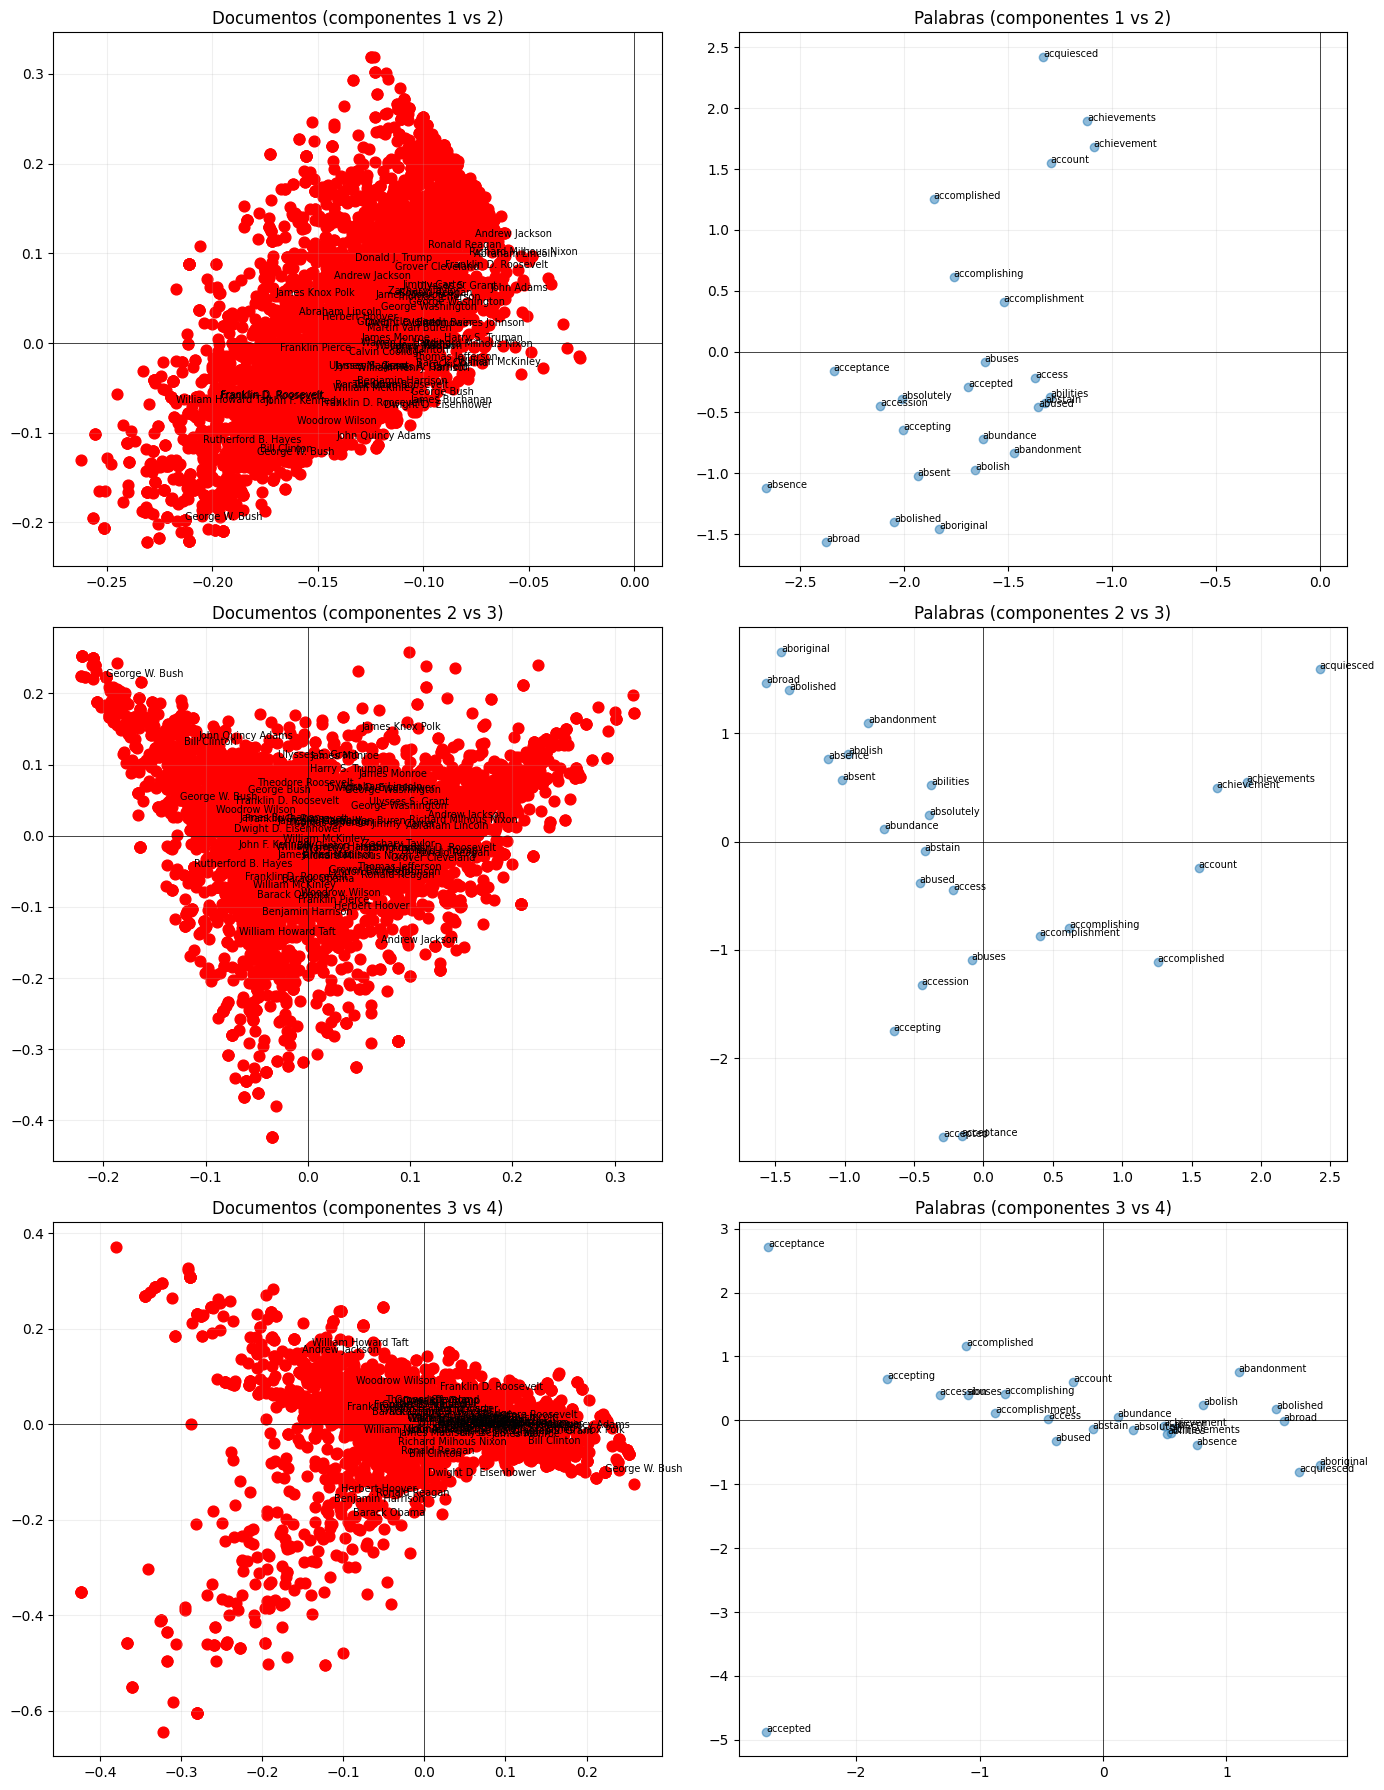

In [18]:

import numpy as np
import matplotlib.pyplot as plt

# =========================
# FUNCIONES
# =========================
def coordenadas_documentos(U, s, componentes):
    i, j = componentes[0]-1, componentes[1]-1
    return np.column_stack((U[:, i] * s[i], U[:, j] * s[j]))

def coordenadas_terminos(VT, s, componentes):
    i, j = componentes[0]-1, componentes[1]-1
    return np.column_stack((VT[i, :] * s[i], VT[j, :] * s[j]))


# =========================
# DATOS
# =========================
vocab = vectorizer_clean.get_feature_names_out()
freq = np.array(X_clean.sum(axis=0)).flatten()
names = df["Name"].values

# =========================
# FIGURA 3 FILAS × 2 COLUMNAS
# =========================
fig, axes = plt.subplots(3, 2, figsize=(14, 18))

pairs = [(1,2), (2,3), (3,4)]
titles = ["1 vs 2", "2 vs 3", "3 vs 4"]

for row, (c1, c2) in enumerate(pairs):

    # =========================
    # COORDENADAS
    # =========================
    docs = coordenadas_documentos(U_clean, s_clean, (c1, c2))
    terms = coordenadas_terminos(VT_clean, s_clean, (c1, c2))

    # =========================
    # DOCUMENTOS (izquierda)
    # =========================
    ax = axes[row, 0]
    ax.scatter(docs[:,0], docs[:,1], c="red", s=60)

    for i, name in enumerate(names):
        ax.text(docs[i,0], docs[i,1], name, fontsize=7)

    ax.set_title(f"Documentos (componentes {c1} vs {c2})")
    ax.axhline(0, color="black", linewidth=0.5)
    ax.axvline(0, color="black", linewidth=0.5)
    ax.grid(alpha=0.2)

    # =========================
    # TÉRMINOS (derecha)
    # =========================
    ax = axes[row, 1]

    top_idx = np.argsort(freq)[-25:]  # palabras más frecuentes

    ax.scatter(terms[top_idx,0], terms[top_idx,1], alpha=0.5)

    for i in top_idx:
        ax.text(
            terms[i,0],
            terms[i,1],
            vocab[i],
            fontsize=7
        )

    ax.set_title(f"Palabras (componentes {c1} vs {c2})")
    ax.axhline(0, color="black", linewidth=0.5)
    ax.axvline(0, color="black", linewidth=0.5)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

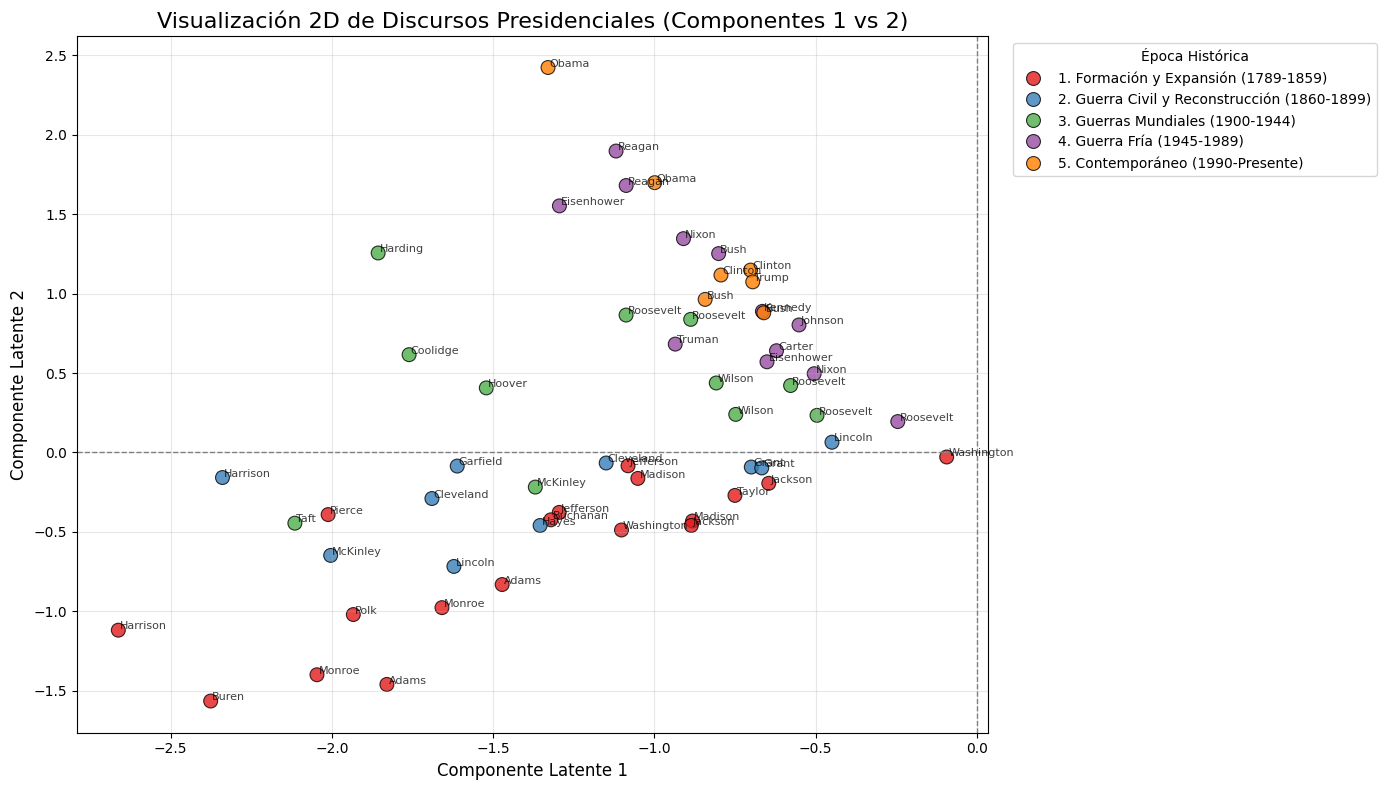

In [19]:
# =========================
# Visualización por período histórico
# =========================
df['Year'] = df['Date'].str.extract(r'(\d{4})').astype(float)

def asignar_periodo(year):
    if year < 1860:
        return '1. Formación y Expansión (1789-1859)'
    elif year < 1900:
        return '2. Guerra Civil y Reconstrucción (1860-1899)'
    elif year < 1945:
        return '3. Guerras Mundiales (1900-1944)'
    elif year < 1990:
        return '4. Guerra Fría (1945-1989)'
    else:
        return '5. Contemporáneo (1990-Presente)'

df['Periodo'] = df['Year'].apply(asignar_periodo)

coords_docs = np.diag(s_clean[:2]) @ VT_clean[:2, :]

plt.figure(figsize=(14, 8))

sns.scatterplot(
    x=coords_docs[0, :], 
    y=coords_docs[1, :], 
    hue=df['Periodo'], 
    palette="Set1", 
    s=100,       
    edgecolor="black", 
    alpha=0.8
)

for i in range(len(df)):
    apellido_presidente = df['Name'].iloc[i].split()[-1] 
    plt.text(
        coords_docs[0, i] + 0.005,  
        coords_docs[1, i] + 0.005,  
        apellido_presidente, 
        fontsize=8,
        alpha=0.75
    )

plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.title('Visualización 2D de Discursos Presidenciales (Componentes 1 vs 2)', fontsize=16)
plt.xlabel('Componente Latente 1', fontsize=12)
plt.ylabel('Componente Latente 2', fontsize=12)

plt.legend(title='Época Histórica', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

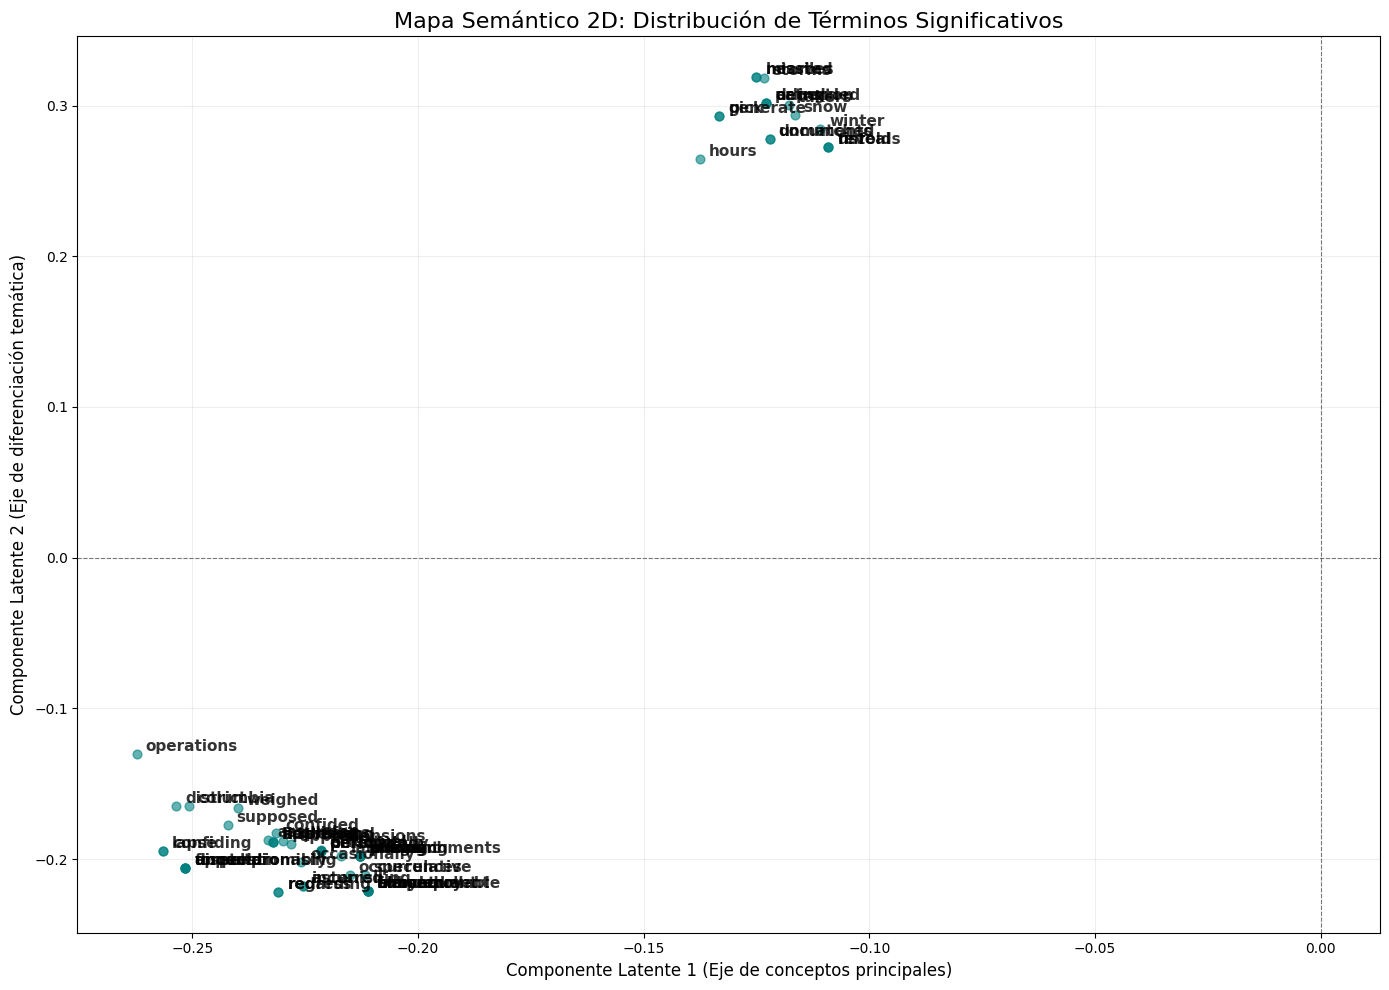

In [22]:

coords_terminos = U_clean[:, :2] @ np.diag(s_clean[:2])

magnitud = np.linalg.norm(coords_terminos, axis=1)
num_palabras_a_mostrar = 60
indices_top = np.argsort(magnitud)[-num_palabras_a_mostrar:]

plt.figure(figsize=(14, 10))

plt.scatter(coords_terminos[indices_top, 0], 
            coords_terminos[indices_top, 1], 
            alpha=0.6, 
            color='teal', 
            s=40)

for i in indices_top:
    plt.text(
        coords_terminos[i, 0] + 0.002, 
        coords_terminos[i, 1] + 0.002, 
        terminos_clean[i], 
        fontsize=11,
        fontweight='bold' if magnitud[i] > np.percentile(magnitud, 95) else 'normal',
        alpha=0.8
    )

plt.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
plt.title('Mapa Semántico 2D: Distribución de Términos Significativos', fontsize=16)
plt.xlabel('Componente Latente 1 (Eje de conceptos principales)', fontsize=12)
plt.ylabel('Componente Latente 2 (Eje de diferenciación temática)', fontsize=12)
plt.grid(alpha=0.2)
plt.tight_layout()

plt.show()

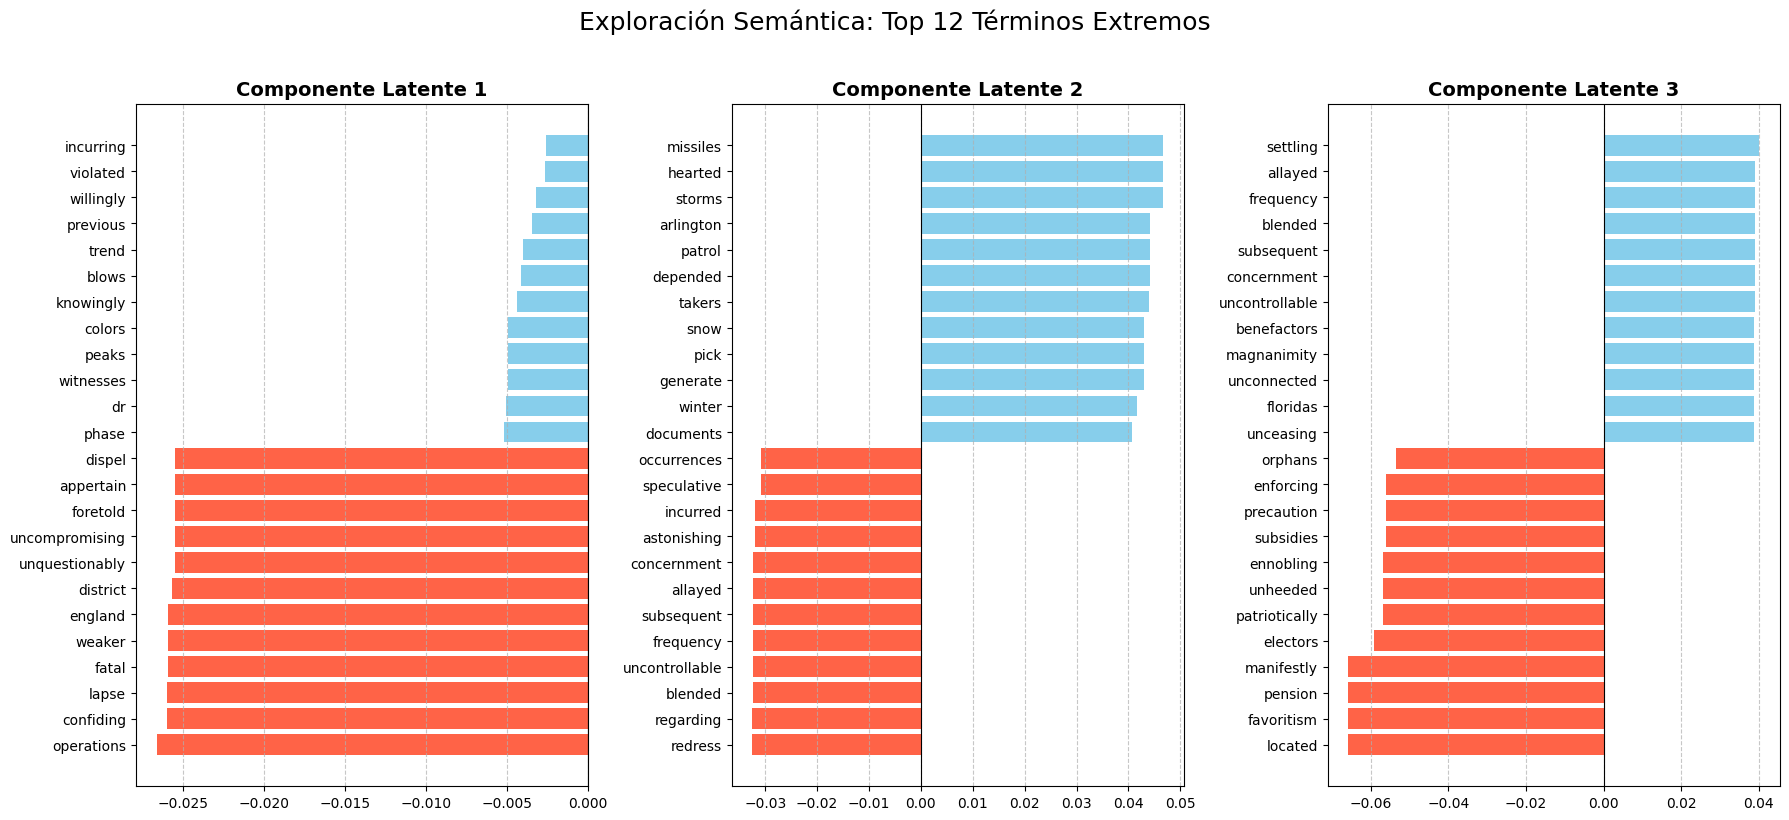

In [23]:
# =========================
# Exploración semántica
# =========================
def graficar_top_terminos(U, terminos, k_componentes=3, n_palabras=10):
    fig, axes = plt.subplots(1, k_componentes, figsize=(18, 8), sharey=False)
    
    for i in range(k_componentes):
        pesos = U[:, i]
        indices_extremos = np.concatenate((np.argsort(pesos)[:n_palabras], 
                                           np.argsort(pesos)[-n_palabras:]))
        
        valores = pesos[indices_extremos]
        nombres = [terminos[idx] for idx in indices_extremos]

        colores = ['tomato'] * n_palabras + ['skyblue'] * n_palabras
    
        axes[i].barh(nombres, valores, color=colores)
        axes[i].set_title(f'Componente Latente {i+1}', fontsize=14, fontweight='bold')
        axes[i].grid(axis='x', linestyle='--', alpha=0.7)
        axes[i].axvline(0, color='black', linewidth=0.8)

    plt.suptitle(f'Exploración Semántica: Top {n_palabras} Términos Extremos', fontsize=18, y=1.02)
    plt.tight_layout()
    plt.show()

graficar_top_terminos(U_clean, terminos_clean, k_componentes=3, n_palabras=12)

## Componente Latente 1:
Este gráfico no está enfocado en un contraste, sino en la frecuencia en que se utilizan ciertas palabras, mientras más larga sea la barra que representa dicho concepto, más relevancia tuvo este en los discursos presidenciales a lo largo de la historia, sin importar la época en que este fue expuesto, por lo que se pueden considerar palabras "base" para estos discursos. Esta exploración es interesante porque nos permite observar las palabras que se han mantenido en el lenguaje a lo largo de la historia y verificar que existe una base compartida en el modelo SVD, antes de buscar diferencias ideológicas. 
## Componente Latente 2:
Este gráfico representa un contraste en las palabras utilizadas para los discursos presidenciales. Aquí, los colores indican una oposición, el modelo detectó que si un discurso se inclina hacia el vocabulario de un color, tiende a alejarse del otro, lo que quiere decir que si un presidente utiliza un término color rojo, rara vez usa uno color azul y viceversa. Esta exploración es relevante porque se conecta directamente con nuestra hipótesis, considerando los periodos históricos, reflejando cambios en el lenguaje y en las prioridades políticas a lo largo del tiempo.
## Componente Latente 3:
Al igual que el gráfico anterior, este representa un contraste en los conceptos, sin embargo, el gráfico anterior lo hacía basándose en la división más general y masiva del corpus. En este caso, el modelo separó los discursos considerando matices particulares, demostrando que existen distintas prioridades y enfoques dependiendo del contexto histórico. Esta exploración es interesante, ya que nos permite entender los debates políticos más específicos para las diferentes épocas registradas y nos muestra la capacidad del modelo para descubrir capas más profundas de información. Así, evidencia que los discursos políticos no se basan en una única tensión principal, sino que se componen de múltiples tópicos de debate ideológico simultáneos.